<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Experiments/Experiments_Word.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leakage-Aware Word Malware Detection

This notebook is testing malware detection features in Word format:

1. Dataset audit and duplicate removal.
2. Detection of class-dependent missingness and suspicious features.
3. Construction of leakage-reduced raw and unified feature sets.
4. Comparison of Logistic Regression, Random Forest, and XGBoost.
5. L1/LASSO feature selection.



**Important:** we do not assume that a suspicious feature is invalid. we separates suspicious features so their effect can be measured explicitly.

In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
DATA_PATH = "/content/Word_All_features.csv"
LABEL_COL = "label"

In [ ]:
# 2. Load data
df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)
display(df.head())
print(df[LABEL_COL].value_counts())

Original shape: (20000, 44)


,ole_object_count,ole_object_type_count,macro_present,dde_present,vba_keywords_count,entropy,struct_ContentType,struct_PartName,file_size,struct_pos,...,path_a-accent1,path_a-sysClr,path_a-lt1,path_/a-accent4,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz,path_a-solidFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId,label
0,21,3,1,0,2,5.296863,0,0,223813,0,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,1
1,0,0,0,1,0,7.415387,14,11,40156,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
2,0,0,0,1,0,7.595452,15,11,258403,0,...,NaN,NaN,NaN,NaN,2283.0,NaN,938.0,0.0,324.0,0
3,0,0,0,1,0,7.402378,14,11,39924,10,...,NaN,NaN,NaN,NaN,2200.0,NaN,938.0,8.0,324.0,0
4,20,3,1,0,2,4.518811,0,0,199559,0,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,1


label
1    10000
0    10000
Name: count, dtype: int64


In [ ]:
# 3. Basic check
check = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
    "unique_count": df.nunique(dropna=True)
}).sort_values(["missing_rate", "unique_count"], ascending=[False, True])

display(check)
print("Exact duplicated rows:", df.duplicated().sum())

,dtype,missing_count,missing_rate,unique_count
path_a-hlink,float64,10000,0.5,2
path_a-accent3,float64,10000,0.5,2
path_a-themeElements,float64,10000,0.5,2
struct_Extension,float64,10000,0.5,2
path_a-dk1,float64,10000,0.5,2
path_a-ln,float64,10000,0.5,2
path_/a-accent6,float64,10000,0.5,2
path_a-lt2,float64,10000,0.5,2
path_a-accent4,float64,10000,0.5,2
path_/a-dk1,float64,10000,0.5,2


Exact duplicated rows: 3395


In [ ]:
# 4. Missingness by class
# A major warning sign is a feature missing almost exclusively in one label.
missing_by_class = (
    df.groupby(LABEL_COL)
      .apply(lambda g: g.isna().mean())
      .T
)
# rename the 0,1 Label columns
missing_by_class.columns = [f"missing_rate_label_{c}" for c in missing_by_class.columns]
missing_by_class["missing_gap"] = (
    missing_by_class.max(axis=1) - missing_by_class.min(axis=1)
)
missing_by_class = missing_by_class.sort_values("missing_gap", ascending=False)

display(missing_by_class.head(30))

/tmp/ipykernel_1321/3928283596.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.isna().mean())


,missing_rate_label_0,missing_rate_label_1,missing_gap
path_a-alpha,1.0,0.0,1.0
struct_dist,1.0,0.0,1.0
path_a-themeElements,1.0,0.0,1.0
struct_Extension,1.0,0.0,1.0
path_/a-effectLst,1.0,0.0,1.0
struct_ang,1.0,0.0,1.0
path_w-p,0.0,1.0,1.0
path_a-accent3,1.0,0.0,1.0
path_a-hlink,1.0,0.0,1.0
path_/w-r,0.0,1.0,1.0


In [ ]:
# 5. Detect suspicious class-dependent features
MISSING_GAP_THRESHOLD = 1

suspicious_missing_cols = missing_by_class.index[
    missing_by_class["missing_gap"] >= MISSING_GAP_THRESHOLD
].tolist()

suspicious_missing_cols = [c for c in suspicious_missing_cols if c != LABEL_COL and c != 'struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz' ]

print("Suspicious class-dependent missingness columns:")
print(suspicious_missing_cols)
print("Count:", len(suspicious_missing_cols))

Suspicious class-dependent missingness columns:
['path_a-alpha', 'struct_dist', 'path_a-themeElements', 'struct_Extension', 'path_/a-effectLst', 'struct_ang', 'path_w-p', 'path_a-accent3', 'path_a-hlink', 'path_/w-r', 'path_w-r', 'path_/w-p', 'path_a-lt1', 'struct_name', 'path_a-lt2', 'path_/a-outerShdw', 'path_a-accent4', 'path_/a-dk1', 'path_a-accent1', 'path_a-sysClr', 'struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill', 'path_/a-accent4', 'path_a-solidFill', 'path_a-ln', 'path_a-dk1', 'path_/a-accent6', 'struct_w', 'struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId', 'struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1']
Count: 29


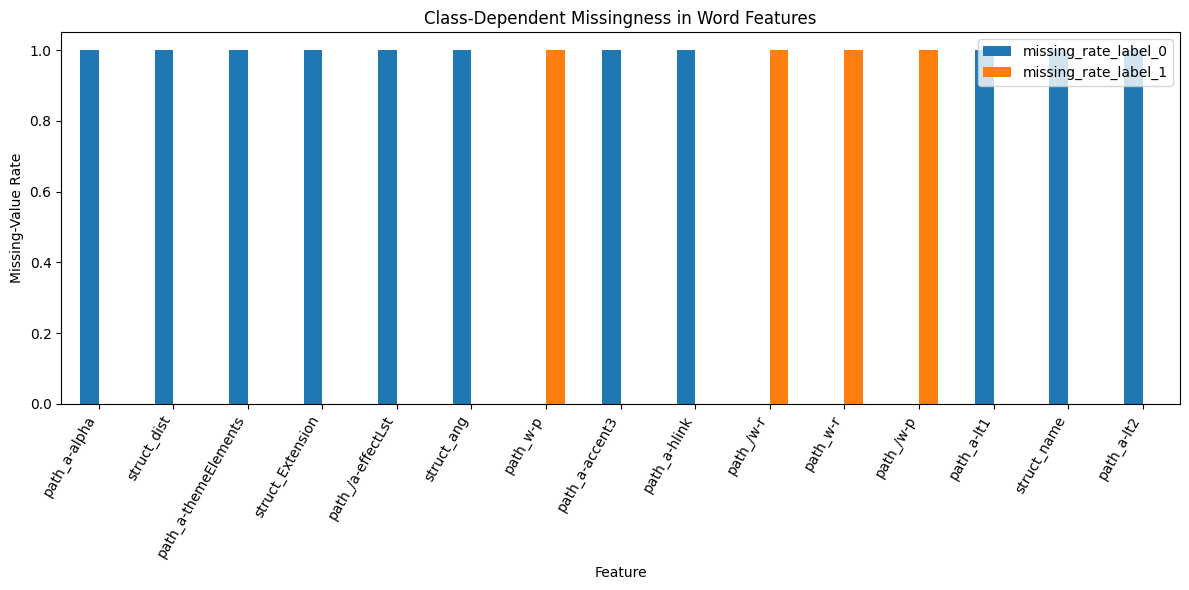

In [ ]:
import os
import matplotlib.pyplot as plt

FIGURE_DIR = "/content/report_figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

top_missing = missing_by_class.head(15)

ax = top_missing[
    ["missing_rate_label_0", "missing_rate_label_1"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_xlabel("Feature")
ax.set_ylabel("Missing-Value Rate")
ax.set_title("Class-Dependent Missingness in Word Features")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/word_missingness_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# 6. Remove exact duplicated rows BEFORE splitting
# Keep a copy so we can know how many duplicates were removed by class.
duplicate_rows = df[df.duplicated(keep=False)]
print("Duplicated-row label counts:")
print(duplicate_rows[LABEL_COL].value_counts())

df_clean = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df_clean.shape)
print("Class counts after duplicate removal:")
print(df_clean[LABEL_COL].value_counts())

Duplicated-row label counts:
label
0    4558
Name: count, dtype: int64
Shape after duplicate removal: (16605, 44)
Class counts after duplicate removal:
label
1    10000
0     6605
Name: count, dtype: int64


In [ ]:
# 7. Detect exactly duplicated feature columns
feature_cols = [c for c in df_clean.columns if c != LABEL_COL]
duplicate_feature_pairs = []

for i, col1 in enumerate(feature_cols):
    for col2 in feature_cols[i + 1:]:
        if df_clean[col1].equals(df_clean[col2]):
            duplicate_feature_pairs.append((col1, col2))

display(pd.DataFrame(duplicate_feature_pairs, columns=["kept_candidate", "duplicate_candidate"]))

# Drop only the second occurrence of each exact duplicate pair.
duplicate_feature_cols_to_drop = sorted({b for _, b in duplicate_feature_pairs})
print("Exact duplicate feature columns to drop:", duplicate_feature_cols_to_drop)

,kept_candidate,duplicate_candidate
0,path_w-r,path_/w-r
1,path_a-hlink,path_a-accent3
2,path_a-hlink,path_a-themeElements
3,path_a-hlink,path_a-dk1
4,path_a-hlink,path_/a-accent6
...,...,...
57,path_/a-dk1,path_a-lt1
58,path_/a-dk1,path_/a-accent4
59,path_a-accent1,path_a-lt1
60,path_a-accent1,path_/a-accent4


Exact duplicate feature columns to drop: ['path_/a-accent4', 'path_/a-accent6', 'path_/a-dk1', 'path_/a-outerShdw', 'path_/w-r', 'path_a-accent1', 'path_a-accent3', 'path_a-accent4', 'path_a-alpha', 'path_a-dk1', 'path_a-lt1', 'path_a-lt2', 'path_a-themeElements', 'struct_dist']


In [ ]:
# 8. Fixed train/test split
# The same test set is used for every model and every training-size experiment.
X = df_clean.drop(columns=[LABEL_COL])
y = df_clean[LABEL_COL]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train_full.shape, y_train.value_counts().to_dict())
print("Test :", X_test_full.shape, y_test.value_counts().to_dict())

Train: (11623, 43) {1: 7000, 0: 4623}
Test : (4982, 43) {1: 3000, 0: 1982}


## Feature sets

We compare three conditions:

- **Raw-All:** all non-duplicate raw features. This shows the optimistic performance of the original representation.
- **Raw-Leakage-Reduced:** exact class-dependent missingness columns are excluded.
- **Unified-Leakage-Reduced:** a small interpretable representation constructed only from leakage-reduced features.


In [ ]:
# 9. Define raw feature sets
raw_all_cols = [
    c for c in X_train_full.columns
    if c not in duplicate_feature_cols_to_drop
]

raw_safe_cols = [
    c for c in raw_all_cols
    if c not in suspicious_missing_cols
]

print("Raw-All features:", len(raw_all_cols))
print("Raw-Safe features:", len(raw_safe_cols))
print("Excluded suspicious features:", len(set(raw_all_cols) - set(raw_safe_cols)))

Raw-All features: 29
Raw-Safe features: 14
Excluded suspicious features: 15


In [ ]:
# 10. Unified feature construction
# NOTES:)
# - log is applied to columns before scaling to handel the outlier.
# - scaler parameters are fitted on training data only to avoid data leakage!!
# - Suspicious class-dependent missingness XML columns are not used in the safe unified set.

BASE_UNIFIED_GROUPS = {
    "file_size": ["file_size"],


    "text_size": [
        "struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz"
    ],

    "embedded_objects": [
        "ole_object_count",
        "ole_object_type_count"
    ],

    "active_content_score": [
        "macro_present",
        "dde_present",
        "vba_keywords_count"
    ],

     "external_reference_count": [
       "path_a-hlink"
    ],

    "obfuscation_score": ["entropy"],

    "structural_complexity_score": [
        "struct_ContentType",
        "struct_PartName",
        "struct_pos",
        "struct_val",
        "struct_typeface",
        "struct_script"
    ]
}

LOG_TRANSFORM_COLS = {
    "file_size"
}

BINARY_COLS = {"macro_present", "dde_present"}


In [ ]:
# @title
# Keep only columns that survived the leakage screen
'''SAFE_UNIFIED_GROUPS = {
    group: [c for c in cols if c in raw_safe_cols]
    for group, cols in BASE_UNIFIED_GROUPS.items()
}
SAFE_UNIFIED_GROUPS = {
    group: cols for group, cols in SAFE_UNIFIED_GROUPS.items() if cols
}

SAFE_UNIFIED_GROUPS'''

'SAFE_UNIFIED_GROUPS = {\n    group: [c for c in cols if c in raw_safe_cols]\n    for group, cols in BASE_UNIFIED_GROUPS.items()\n}\nSAFE_UNIFIED_GROUPS = {\n    group: cols for group, cols in SAFE_UNIFIED_GROUPS.items() if cols\n}\n\nSAFE_UNIFIED_GROUPS'

In [ ]:
from sklearn.utils.extmath import density
# 11. Fit/transform unified features without leakage
def fit_unified_transformer(X_train, groups): # learn scale from train set
    state = {}
    for group_name, cols in groups.items():
        numeric_cols = [c for c in cols if c not in BINARY_COLS]
        scaler = None

        if numeric_cols:
            train_num = X_train[numeric_cols].copy().fillna(0)
            for col in numeric_cols:
                if col in LOG_TRANSFORM_COLS:
                    train_num[col] = np.log1p(train_num[col].clip(lower=0))

            scaler = MinMaxScaler()
            scaler.fit(train_num)

        state[group_name] = {
            "columns": cols,
            "numeric_columns": numeric_cols,
            "binary_columns": [c for c in cols if c in BINARY_COLS],
            "scaler": scaler
        }
    return state


def transform_unified(X, state):
    output = pd.DataFrame(index=X.index)

    for group_name, config in state.items():
        components = []

        numeric_cols = config["numeric_columns"]
        if numeric_cols:
            values = X[numeric_cols].copy().fillna(0)
            for col in numeric_cols:
                if col in LOG_TRANSFORM_COLS:
                    values[col] = np.log1p(values[col].clip(lower=0))

            scaled = config["scaler"].transform(values)
            components.append(pd.Series(scaled.mean(axis=1), index=X.index))

        binary_cols = config["binary_columns"]
        if binary_cols:
            # max = presence of any active binary indicator
            binary_score = X[binary_cols].fillna(0).max(axis=1)
            components.append(binary_score)

        output[group_name] = pd.concat(components, axis=1).mean(axis=1)

        if group_name == "embedded_objects_score":
          count = X["ole_object_count"].fillna(0).clip(lower=0)
          type_count = X["ole_object_type_count"].fillna(0).clip(lower=0)
          embedded_object_diversity = np.where(
              count > 0, type_count / count, 0
          )
          output[group_name] = (output[group_name]  + embedded_object_diversity)/2


    if {"vba_keywords_count", "file_size"}.issubset(X.columns):
        size_kb = X["file_size"].fillna(0).clip(lower=0) / 1024
        vba = X["vba_keywords_count"].fillna(0).clip(lower=0)
        output["active_content_density"] = np.where(
            size_kb > 0, vba / size_kb, 0
        )

        # just to arrange the feature in dataframe
        density_col = output.pop("active_content_density")
        insert_position = (output.columns.get_loc("active_content_score") + 1)
        output.insert(insert_position, "active_content_density", density_col)


    return output.replace([np.inf, -np.inf], 0).fillna(0)


unified_state = fit_unified_transformer(
    X_train_full[raw_all_cols],
    BASE_UNIFIED_GROUPS
)

X_train_unified = transform_unified(
    X_train_full[raw_all_cols],
    unified_state
)


X_test_unified = transform_unified(
    X_test_full[raw_all_cols],
    unified_state
)

print("Unified train shape:", X_train_unified.shape)
display(X_train_unified.head())

Unified train shape: (11623, 8)


,file_size,text_size,embedded_objects,active_content_score,active_content_density,external_reference_count,obfuscation_score,structural_complexity_score
996,0.691509,0.000000,0.630,0.666667,0.008604,0.0,0.742527,0.000000
1477,0.673331,0.000000,0.685,0.666667,0.011914,1.0,0.711234,0.598625
12939,0.587027,0.270337,0.000,0.500000,0.000000,0.0,0.962371,0.616657
1426,0.679793,0.000000,0.600,0.666667,0.010612,1.0,0.584018,0.598625
10730,0.537004,0.000492,0.000,0.500000,0.000000,0.0,0.819155,0.592533


In [ ]:
# @title
# save the Unified features Dataframe
''' df_train = pd.concat([X_train_unified, y_train], axis=1)
df_train.to_csv("X_train_unified.csv", index=False)
df_test = pd.concat([X_test_unified, y_test], axis=1)
df_test.to_csv("X_test_unified.csv", index=False)
Word_unified_features = pd.concat([df_train, df_test], axis=0)
Word_unified_features.to_csv("Word_unified_features.csv", index=False) '''

' df_train = pd.concat([X_train_unified, y_train], axis=1)\ndf_train.to_csv("X_train_unified.csv", index=False)\ndf_test = pd.concat([X_test_unified, y_test], axis=1)\ndf_test.to_csv("X_test_unified.csv", index=False)\nWord_unified_features = pd.concat([df_train, df_test], axis=0)\nWord_unified_features.to_csv("Word_unified_features.csv", index=False) '

In [ ]:
# 12. Model definitions
models = {
    "Logistic_L1": Pipeline([
        ("imputer", SimpleImputer(strategy='constant', fill_value=0)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=1.0,
            max_iter=100,
            random_state=RANDOM_STATE
        ))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy='constant', fill_value=0)),
        ("model", RandomForestClassifier(
            n_estimators=25,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

     "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy='constant', fill_value=0)),
        ("model", XGBClassifier(
            n_estimators=25,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])
}




In [ ]:
# 13. Evaluation helper
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, feature_set):
    fitted = clone(model)
    fitted.fit(X_train, y_train)

    pred = fitted.predict(X_test)

    if hasattr(fitted, "predict_proba"):
        score = fitted.predict_proba(X_test)[:, 1]
    else:
        score = fitted.decision_function(X_test)

    return fitted, {
        "feature_set": feature_set,
        "model": model_name,
        "n_features": X_train.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro",),
        "recall_macro": recall_score(y_test, pred, average="macro"),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "roc_auc": roc_auc_score(y_test, score),
        "pr_auc": average_precision_score(y_test, score)
    }

In [ ]:
# 14. Compare Raw-All, Raw-Safe, and Unified-Safe
feature_sets = {
    "Raw_All": (
        X_train_full[raw_all_cols],
        X_test_full[raw_all_cols]
    ),
    "Raw_Leakage_Reduced": (
        X_train_full[raw_safe_cols],
        X_test_full[raw_safe_cols]
    ),
    "Unified_Leakage_Reduced": (
        X_train_unified,
        X_test_unified
    )
}

comparison_results = []
fitted_models = {}

for feature_set_name, (Xtr, Xte) in feature_sets.items():
    for model_name, model in models.items():
        fitted, result = evaluate_model(
            model, Xtr, y_train, Xte, y_test,
            model_name=model_name,
            feature_set=feature_set_name
        )
        comparison_results.append(result)
        fitted_models[(feature_set_name, model_name)] = fitted

comparison_df = pd.DataFrame(comparison_results).sort_values(
    ["f1_macro", "pr_auc"], ascending=False
)

display(comparison_df)
comparison_df.to_csv("model_comparison_results.csv", index=False)

,feature_set,model,n_features,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,pr_auc
0,Raw_All,Logistic_L1,29,1.000000,1.000000,1.000000,1.000000,1.0,1.0
1,Raw_All,RandomForest,29,1.000000,1.000000,1.000000,1.000000,1.0,1.0
3,Raw_Leakage_Reduced,Logistic_L1,14,1.000000,1.000000,1.000000,1.000000,1.0,1.0
4,Raw_Leakage_Reduced,RandomForest,14,1.000000,1.000000,1.000000,1.000000,1.0,1.0
6,Unified_Leakage_Reduced,Logistic_L1,8,1.000000,1.000000,1.000000,1.000000,1.0,1.0
7,Unified_Leakage_Reduced,RandomForest,8,1.000000,1.000000,1.000000,1.000000,1.0,1.0
2,Raw_All,XGBoost,29,0.999599,0.999496,0.999667,0.999581,1.0,1.0
5,Raw_Leakage_Reduced,XGBoost,14,0.999599,0.999496,0.999667,0.999581,1.0,1.0
8,Unified_Leakage_Reduced,XGBoost,8,0.999599,0.999496,0.999667,0.999581,1.0,1.0


# under sampling experiments

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Create undersampler
rus = RandomUnderSampler(
    sampling_strategy=1.0,
    random_state=RANDOM_STATE
)

undersampling_results = []

for feature_set_name, (Xtr, Xte) in feature_sets.items():

    # Apply undersampling ONLY to training data
    Xtr_under, ytr_under = rus.fit_resample(Xtr, y_train)

    print(f"\n{feature_set_name}")
    print("Before:", y_train.value_counts().to_dict())
    print("After :", ytr_under.value_counts().to_dict())

    # Train and evaluate the same models
    for model_name, model in models.items():

        _, result = evaluate_model(
            model,
            Xtr_under,
            ytr_under,
            Xte,          # original test set
            y_test,       # original test labels
            model_name=model_name,
            feature_set=f"{feature_set_name}_Undersampled"
        )

        undersampling_results.append(result)


Raw_All
Before: {1: 7000, 0: 4623}
After : {0: 4623, 1: 4623}

Raw_Leakage_Reduced
Before: {1: 7000, 0: 4623}
After : {0: 4623, 1: 4623}

Unified_Leakage_Reduced
Before: {1: 7000, 0: 4623}
After : {0: 4623, 1: 4623}


In [ ]:
undersampling_df = pd.DataFrame(undersampling_results)

display(undersampling_df)

,feature_set,model,n_features,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,pr_auc
0,Raw_All_Undersampled,Logistic_L1,29,1.000000,1.000000,1.000000,1.000000,1.0,1.0
1,Raw_All_Undersampled,RandomForest,29,1.000000,1.000000,1.000000,1.000000,1.0,1.0
2,Raw_All_Undersampled,XGBoost,29,0.999599,0.999496,0.999667,0.999581,1.0,1.0
3,Raw_Leakage_Reduced_Undersampled,Logistic_L1,14,1.000000,1.000000,1.000000,1.000000,1.0,1.0
4,Raw_Leakage_Reduced_Undersampled,RandomForest,14,1.000000,1.000000,1.000000,1.000000,1.0,1.0
5,Raw_Leakage_Reduced_Undersampled,XGBoost,14,0.999599,0.999496,0.999667,0.999581,1.0,1.0
6,Unified_Leakage_Reduced_Undersampled,Logistic_L1,8,1.000000,1.000000,1.000000,1.000000,1.0,1.0
7,Unified_Leakage_Reduced_Undersampled,RandomForest,8,1.000000,1.000000,1.000000,1.000000,1.0,1.0
8,Unified_Leakage_Reduced_Undersampled,XGBoost,8,0.999599,0.999496,0.999667,0.999581,1.0,1.0


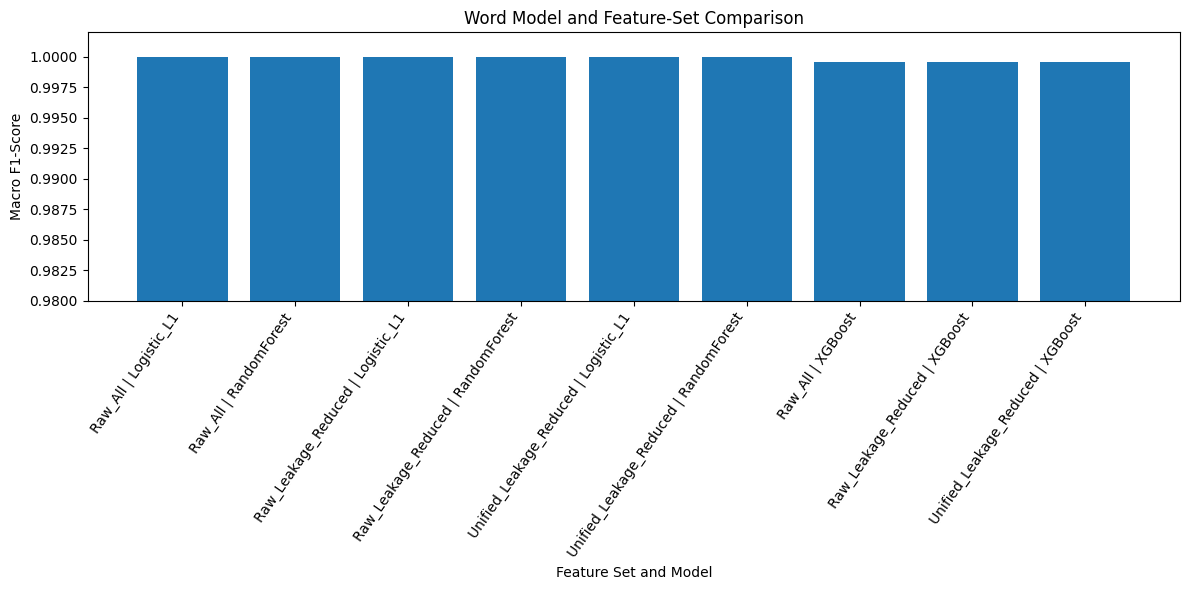

In [ ]:
# 15. Visual comparison
plot_df = comparison_df.copy()

labels = (
    plot_df["feature_set"]
    + " | "
    + plot_df["model"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    labels,
    plot_df["f1_macro"]
)

plt.xticks(
    rotation=55,
    ha="right"
)

plt.xlabel("Feature Set and Model")
plt.ylabel("Macro F1-Score")
plt.title("Word Model and Feature-Set Comparison")
plt.ylim(0.98, 1.002)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/word_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# 16. L1/LASSO selected features from raw data
lasso_model = fitted_models[("Raw_All", "Logistic_L1")]
coef = lasso_model.named_steps["model"].coef_[0]

lasso_features = pd.DataFrame({
    "feature": raw_all_cols,
    "coefficient": coef,
    "absolute_coefficient": np.abs(coef)
}).sort_values("absolute_coefficient", ascending=False)

selected_lasso_features = lasso_features.loc[
    lasso_features["absolute_coefficient"] > 1e-8, "feature"
].tolist()

display(lasso_features)
print("Selected by L1:", len(selected_lasso_features))
print(selected_lasso_features)
lasso_features.to_csv("lasso_feature_ranking.csv", index=False)

,feature,coefficient,absolute_coefficient
1,ole_object_type_count,2.916101,2.916101
4,vba_keywords_count,1.515245,1.515245
2,macro_present,1.236282,1.236282
3,dde_present,-1.067252,1.067252
0,ole_object_count,0.941527,0.941527
6,struct_ContentType,-0.699687,0.699687
28,struct_{http://schemas.openxmlformats.org/word...,-0.646620,0.646620
27,struct_{http://schemas.openxmlformats.org/word...,-0.329908,0.329908
19,struct_Extension,0.228838,0.228838
24,struct_{http://schemas.openxmlformats.org/word...,-0.219350,0.219350


Selected by L1: 12
['ole_object_type_count', 'vba_keywords_count', 'macro_present', 'dde_present', 'ole_object_count', 'struct_ContentType', 'struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId', 'struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1', 'struct_Extension', 'struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz', 'struct_PartName', 'struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill']


In [ ]:
# 17. Evaluate LASSO-selected raw feature subset
if selected_lasso_features:
    selected_results = []

    for model_name, model in models.items():
        _, result = evaluate_model(
            model,
            X_train_full[selected_lasso_features],
            y_train,
            X_test_full[selected_lasso_features],
            y_test,
            model_name=model_name,
            feature_set="LASSO_Selected_Raw"
        )
        selected_results.append(result)

    selected_df = pd.DataFrame(selected_results)
    display(selected_df)

    comparison_df = pd.concat(
        [comparison_df, selected_df],
        ignore_index=True
    ).sort_values(["f1_macro", "pr_auc"], ascending=False)

    comparison_df.to_csv("model_comparison_results.csv", index=False)

,feature_set,model,n_features,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,pr_auc
0,LASSO_Selected_Raw,Logistic_L1,12,1.0,1.0,1.0,1.0,1.0,1.0
1,LASSO_Selected_Raw,RandomForest,12,1.0,1.0,1.0,1.0,1.0,1.0
2,LASSO_Selected_Raw,XGBoost,12,1.0,1.0,1.0,1.0,1.0,1.0


# conclusions


- Removing exact duplicated samples and exact duplicated columns reduced redundancy.
- A strong class-dependent missingness pattern was observed in several XML/path features.
- Performance was the same before and after excluding those suspicious features.
- Unified features reduced dimensionality while preserving predictive performance.
- L1 regularization provided 12 selected feature.
- A 100% accuracy rate is not an automatic guarantee of real-world detection accuracy; this may depend on how the data is collected.